In [1]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,
)

<IPython.core.display.Javascript object>

In [137]:
import numpy as np
from boolean_analysis import calculate_fourier_transform_matrix, parity_of_1s
import pandas as pd

%matplotlib inline

In [129]:
class BooleanFourierLearner:
    def __init__(self, number_spins: int, subsets: np.ndarray = None):
        self.number_spins = number_spins
        if subsets is not None:
            self.subsets = subsets
        else:
            self.subsets = np.arange(2**number_spins, dtype="uint64")
        self.coeffs_ = None

    def fit(
        self,
        x: np.array,
        y: np.array,
        batch_size=None,
        stochastic_iterations=None,
    ):
        if len(x) != len(y):
            raise ValueError("Lengths of x and y should coincide")
        if stochastic_iterations is None:
            stochastic_iterations = 1
            stochastic = False
        else:
            stochastic = True

        sample_size = len(x)
        if batch_size:
            n_batches = sample_size // batch_size + (
                sample_size % batch_size != 0
            )
        else:
            n_batches = 1
            batch_size = sample_size

        sumprod = np.zeros(len(self.subsets), dtype="float64")

        for j in range(stochastic_iterations):
            for i in range(n_batches):
                if not stochastic:
                    x_batch = x[i * batch_size : (i + 1) * batch_size]
                    y_batch = y[i * batch_size : (i + 1) * batch_size]
                else:
                    indicies = np.random.choice(
                        np.arange(sample_size), batch_size, replace=False
                    )
                    x_batch = x[indicies]
                    y_batch = y[indicies]

                fourier_transform_matrix = calculate_fourier_transform_matrix(
                    x_batch, self.subsets, self.number_spins
                )

                sumprod += (fourier_transform_matrix.T @ y_batch).astype(
                    "float64"
                )

        self.coeffs_ = sumprod / sample_size / stochastic_iterations
    

In [130]:
number_spins = 4
x = np.arange(2**number_spins, dtype="uint64")
y = parity_of_1s(x & 6, n=number_spins).astype("int8") * 2 - 1
for batch_size in range(len(x)):
    learner = BooleanFourierLearner(number_spins=number_spins)
    learner.fit(x, y, batch_size=batch_size)
    assert (
        np.isclose(
            learner.coeffs_,
            np.array(
                [
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    1.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                ]
            ),
        )
    ).all()

In [135]:
x = np.arange(2**number_spins, dtype="uint64")
y = parity_of_1s(x & 6, n=number_spins).astype("int8") * 2 - 1
learner = BooleanFourierLearner(number_spins=number_spins)
learner.fit(x, y, batch_size=2, stochastic_iterations=1000)
learner.coeffs_

array([-3.1250e-03, -7.5000e-04,  1.7500e-03, -1.7625e-02,  1.2625e-02,
       -3.0000e-03,  1.0000e+00, -3.3750e-03,  1.4750e-02,  2.3750e-03,
        9.1250e-03, -5.0000e-04, -4.2500e-03,  3.3750e-03, -4.8750e-03,
        4.5000e-03])

<AxesSubplot: >

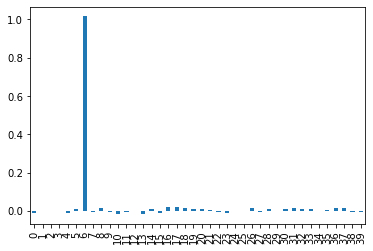

In [144]:
number_spins = 10
x = np.arange(2**number_spins, dtype="uint64")
y = parity_of_1s(x & 6, n=number_spins).astype("int8") * 2 - 1
learner = BooleanFourierLearner(number_spins=number_spins)
learner.fit(x, y, batch_size=20, stochastic_iterations=10)
pd.Series(learner.coeffs_[:40]).plot.bar()